# Chapter 7: Lie Groups

**Source Span.** `Introduction to Smooth Manifolds.pdf`, printed pages `150-173`.
The course source map identifies this chapter as: basic Lie groups, homomorphisms,
subgroups, actions, equivariant maps, and examples. I inspected the PDF span using
`pdftotext` with an 18-page PDF offset: physical pages `168-191` correspond to
printed pages `150-173`.

**Chapter Goal.** Learn the first layer of Lie group theory as a set of visible and
testable structures: a group law that is smooth, matrix groups cut out by equations
or inequalities, homomorphisms with constant rank, subgroups as submanifolds,
actions through orbits and stabilizers, equivariant maps, semidirect products, and
representations.

This notebook is original teaching material. It uses the source only for structure,
terminology, theorem orientation, and page span metadata; it does not copy textbook
prose, exercises, screenshots, or figures.


## Visual Storyboard

1. **Lie group grammar.** A dependency diagram separates the smooth-manifold
requirements from the algebraic group requirements, then shows how translations
turn local information at the identity into information everywhere.
2. **Matrix group atlas.** A determinant-level picture for `GL(2,R)`, `GL^+(2,R)`,
`SL(2,R)`, and samples from `O(2)` makes open subgroups, kernels, and level sets
inspectable.
3. **Homomorphism and covering.** The map `epsilon: R -> S^1` wraps a line around
the circle; the integer kernel is drawn and checked numerically.
4. **Dense immersed subgroup.** An irrational one-parameter subgroup in the flat
torus illustrates how an injective homomorphism can produce an immersed subgroup
whose image is not embedded.
5. **Actions, orbits, stabilizers.** The `SO(2)` action on the plane displays
circle orbits, the fixed origin, and the contrast between trivial and nontrivial
isotropy.
6. **Equivariant rank diagram.** A commutative square and tangent-square diagram
encode why transitive equivariance forces constant rank.
7. **Semidirect product lab.** The Euclidean group `R^2 semidirect SO(2)` moves a
triangle while preserving distances and orientation.
8. **Representation table.** Matrix representations from the chapter are routed to
checks for faithfulness, kernels, and preserved structure.


## Library Routing

| Concept | Representation | Library | Why this route | Check or artifact |
| --- | --- | --- | --- | --- |
| Definition of Lie group and translations | Dependency graph plus `S^1` arithmetic | NetworkX, Matplotlib, NumPy | A graph is the right object for the definition, while circle arithmetic shows smooth product and inverse in coordinates. | `lie-group-structure-translations.png`, `lie-group-s1-axioms.json` |
| Matrix groups and subgroups | Determinant level-set plot | Matplotlib, SymPy, NumPy | Matrix examples are equation/inequality driven, so a level plot plus exact determinant identities exposes the geometry. | `matrix-groups-det-levels.png`, `matrix-subgroup-invariants.json` |
| Homomorphisms and covering groups | Line-to-circle wrapping diagram | Matplotlib, NumPy | The quotient-like behavior of `R -> S^1` is easiest to inspect by seeing fibers over the circle. | `homomorphism-covering-circle.png`, `homomorphism-covering-kernel.json` |
| Dense Lie subgroup | Irrational flow on the flat torus | Matplotlib, NumPy | A flat torus fundamental square makes nonembedded density visible without needing 3D. | `dense-torus-subgroup.png`, `dense-torus-subgroup.json` |
| Actions, orbits, stabilizers | Orbit plot and interactive rotation | Matplotlib, Plotly, NumPy | Static orbits show stabilizers; the HTML file lets the learner inspect the action as a family of diffeomorphisms. | `actions-orbits-stabilizers.png`, `so2-action-orbits.html` |
| Equivariant maps and rank | Commutative diagram plus numeric rank samples | NetworkX, Matplotlib, NumPy | The theorem is a diagram chase; rank samples keep the statement computationally honest. | `equivariant-rank-diagram.png`, `equivariant-rank-check.json` |
| Semidirect products and Euclidean group | Transformed triangle with invariant table | Matplotlib, NumPy | Semidirect multiplication becomes concrete as rotate-then-translate motion. | `semidirect-euclidean-action.png`, `semidirect-euclidean-group.json` |
| Representations | CSV summary and block-matrix checks | SymPy, NumPy | Representations are homomorphisms into matrix groups, so tables and exact block products are enough. | `representation-examples.csv`, `representation-checks.json` |


In [1]:
from __future__ import annotations

import csv
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Introduction-to-Smooth-Manifolds course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "chapter-07-lie-groups"
UNIT_TITLE = "Lie Groups"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def rel(path: Path) -> str:
    return str(path.resolve().relative_to(BOOK_ROOT.resolve())).replace("\\", "/")

def display_chapter_artifact(path: Path, *, width: int = 760, height: int = 520) -> None:
    candidate = Path(path)
    if candidate.is_absolute():
        candidate = Path("..") / candidate.resolve().relative_to(BOOK_ROOT.resolve())
    display_artifact(candidate, width=width, height=height)

print(f"Book root: {BOOK_ROOT.name}")
print(f"Artifact root: {rel(ARTIFACT_ROOT)}")


Book root: Introduction-to-Smooth-Manifolds
Artifact root: artifacts/chapter-07-lie-groups


In [2]:
library_routing_rows = [
    {
        "concept": "Lie group definition and translations",
        "representation": "dependency diagram plus S^1 arithmetic",
        "library": "NetworkX, Matplotlib, NumPy",
        "why": "separates definition inputs from translation consequences",
        "artifact_or_check": "lie-group-structure-translations.png; lie-group-s1-axioms.json",
    },
    {
        "concept": "matrix Lie groups",
        "representation": "determinant level-set window",
        "library": "Matplotlib, SymPy, NumPy",
        "why": "open subsets, kernels, and orthogonal equations are visible as equations",
        "artifact_or_check": "matrix-groups-det-levels.png; matrix-subgroup-invariants.json",
    },
    {
        "concept": "homomorphisms and covering groups",
        "representation": "R wrapping around S^1 with integer kernel",
        "library": "Matplotlib, NumPy",
        "why": "fibers and kernel are easier to inspect as a line-to-circle map",
        "artifact_or_check": "homomorphism-covering-circle.png; homomorphism-covering-kernel.json",
    },
    {
        "concept": "immersed nonembedded subgroup",
        "representation": "irrational flow in the flat torus",
        "library": "Matplotlib, NumPy",
        "why": "the unit square model makes dense image behavior inspectable",
        "artifact_or_check": "dense-torus-subgroup.png; dense-torus-subgroup.json",
    },
    {
        "concept": "actions, orbits, stabilizers",
        "representation": "SO(2) orbit plot and action HTML",
        "library": "Matplotlib, Plotly, NumPy",
        "why": "static orbits show stabilizers; HTML shows the action family",
        "artifact_or_check": "actions-orbits-stabilizers.png; so2-action-orbits.html",
    },
    {
        "concept": "equivariant maps",
        "representation": "commutative square and rank samples",
        "library": "NetworkX, Matplotlib, NumPy",
        "why": "the theorem is a diagram chase with transported tangent maps",
        "artifact_or_check": "equivariant-rank-diagram.png; equivariant-rank-check.json",
    },
    {
        "concept": "semidirect products",
        "representation": "Euclidean motion of a triangle",
        "library": "Matplotlib, NumPy",
        "why": "rotate-then-translate reveals the twisted product law",
        "artifact_or_check": "semidirect-euclidean-action.png; semidirect-euclidean-group.json",
    },
    {
        "concept": "representations",
        "representation": "matrix homomorphism table and block-matrix checks",
        "library": "SymPy, NumPy",
        "why": "representations are homomorphisms into GL(V), so matrices are the natural object",
        "artifact_or_check": "representation-examples.csv; representation-checks.json",
    },
]

concept_inventory_rows = [
    {"concept": "Lie group", "learner_question": "Which operations must be smooth?", "check": "S^1 product and inverse residuals"},
    {"concept": "translation", "learner_question": "How does identity data move globally?", "check": "left translation chord-distance residual"},
    {"concept": "homomorphism", "learner_question": "Does F(gh)=F(g)F(h) hold?", "check": "epsilon homomorphism residual"},
    {"concept": "kernel", "learner_question": "Which elements map to the identity?", "check": "integer samples hit identity"},
    {"concept": "Lie subgroup", "learner_question": "Is the subgroup embedded, open, closed, or immersed?", "check": "determinant kernel and dense torus coverage"},
    {"concept": "group action", "learner_question": "What diffeomorphism does each group element define?", "check": "SO(2) radius preservation"},
    {"concept": "orbit", "learner_question": "What image does the orbit map trace?", "check": "rank one for nonzero SO(2) orbit"},
    {"concept": "stabilizer", "learner_question": "Which group elements fix the point?", "check": "origin fixed by sampled rotations"},
    {"concept": "equivariant map", "learner_question": "Does the action commute with the map?", "check": "epsilon_2 equivariance residual"},
    {"concept": "semidirect product", "learner_question": "Where does the twist enter multiplication?", "check": "Euclidean associativity and inverse residuals"},
    {"concept": "representation", "learner_question": "Is the matrix homomorphism faithful?", "check": "block translation and periodic-kernel checks"},
]

library_routing_path = save_csv(library_routing_rows, TABLES / "lie-groups-routing.csv")
concept_inventory_path = save_csv(concept_inventory_rows, TABLES / "concept-inventory.csv")
display_chapter_artifact(library_routing_path)
display_chapter_artifact(concept_inventory_path)


[lie-groups-routing.csv](../artifacts/chapter-07-lie-groups/tables/lie-groups-routing.csv)

[concept-inventory.csv](../artifacts/chapter-07-lie-groups/tables/concept-inventory.csv)

## Translation Guide

The chapter repeatedly asks the same conversion question:

| Book-side phrase | Computational model in this notebook |
| --- | --- |
| Smooth multiplication and inversion | coordinate formulas on `S^1` and polynomial/rational matrix formulas |
| Left and right translation | diffeomorphisms that move identity-based data to arbitrary group elements |
| Homomorphism | a map satisfying `F(gh)=F(g)F(h)` plus a constant-rank differential check |
| Kernel | a level set over the identity, therefore a candidate embedded Lie subgroup |
| Open or closed subgroup | a visible component or level-set condition inside a larger group |
| Group action | a family of diffeomorphisms indexed by group elements |
| Orbit and stabilizer | image and fiber of the orbit map `g -> g.p` |
| Equivariant map | a commutative square that transports rank information |
| Semidirect product | a product manifold with multiplication twisted by an action |
| Representation | a homomorphism into `GL(V)`, often displayed as matrices acting on vectors |

The computational checks below are not replacements for proofs. Their purpose is
to make the definitions and theorem hypotheses inspectable: closure, inverse,
homomorphism residual, rank, subgroup equation, orbit dimension, isotropy, and
distance preservation.


## Concept Inventory

- **Basic Lie group definition:** a boundaryless smooth manifold with smooth
group multiplication and inversion; `S^1`, `R^n`, `GL(n,R)`, tori, and discrete
groups are first examples.
- **Translations:** left and right multiplication by a fixed group element are
diffeomorphisms; they explain why identity-level calculations propagate through
the whole group.
- **Homomorphisms:** smooth group homomorphisms have constant rank; bijective
ones are Lie group isomorphisms.
- **Universal covering groups:** connected Lie groups lift their group law to a
simply connected covering Lie group, with `R^n -> T^n` and `C -> C*` as models.
- **Lie subgroups:** embedded subgroups automatically inherit Lie group
structures; kernels are properly embedded; injective images can be immersed and
may be dense rather than embedded.
- **Closed versus embedded:** in Lie groups, embedded Lie subgroups are closed,
and closed Lie subgroups are embedded; this is much stronger than for arbitrary
immersed submanifolds.
- **Group actions:** smooth actions produce orbits and stabilizers; orbit maps
have constant rank, and trivial stabilizer makes an orbit map an injective
immersion.
- **Equivariant maps:** equivariance with a transitive domain action forces
constant rank by transporting the differential through action diffeomorphisms.
- **Matrix group examples:** `O(n)`, `SO(n)`, `U(n)`, and `SU(n)` are recognized
by equations such as `A.T A = I` or `A* A = I` plus determinant restrictions.
- **Semidirect products and representations:** actions by automorphisms build new
Lie groups; representations realize Lie groups as matrix groups when faithful.


## 1. Lie Group Grammar and Translations

A Lie group has two compatible grammars at once. The group grammar gives
identity, product, and inverse. The manifold grammar asks those operations to be
smooth. The payoff is that multiplication by a fixed element is a diffeomorphism,
so a computation made at the identity can be transported everywhere.

The diagram below is deliberately small: every arrow is either part of the
definition or a standard consequence used later in the chapter.


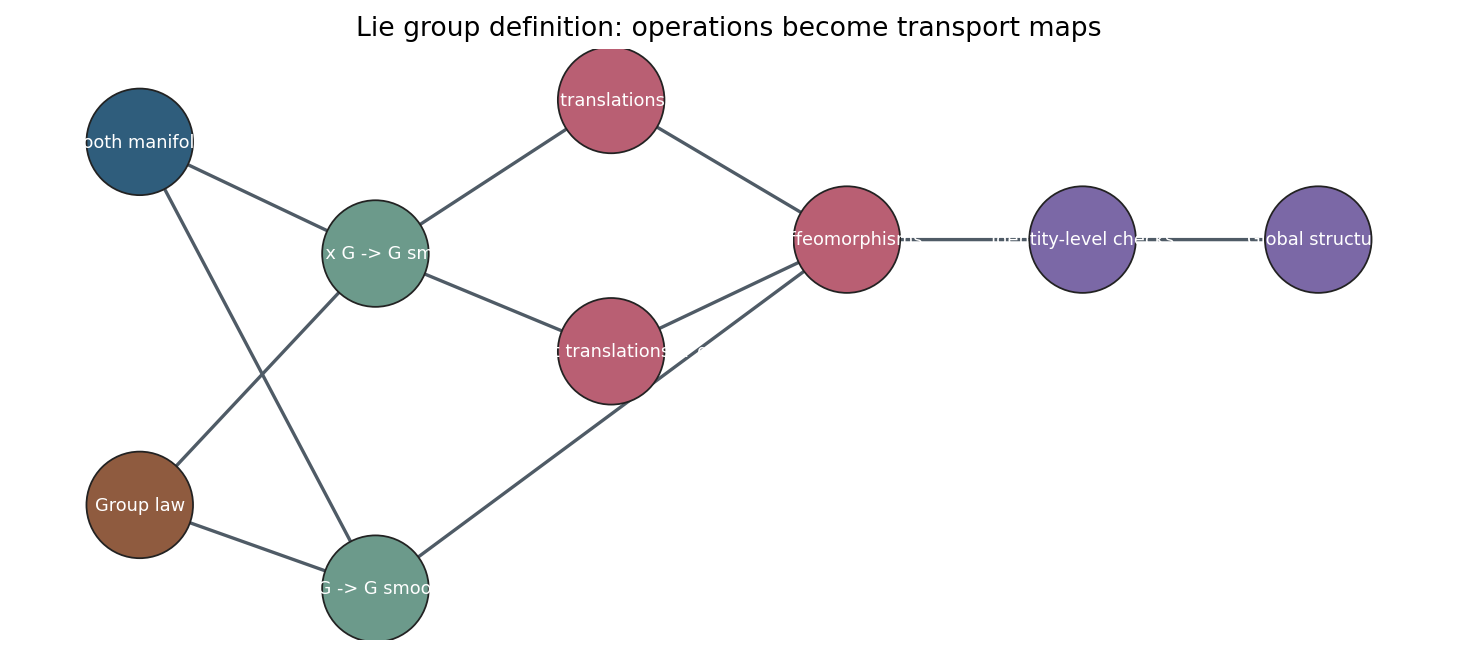

In [3]:
Gdef = nx.DiGraph()
nodes = {
    "Smooth manifold G": "manifold",
    "Group law": "group",
    "m: G x G -> G smooth": "definition",
    "i: G -> G smooth": "definition",
    "Left translations L_g": "consequence",
    "Right translations R_g": "consequence",
    "Diffeomorphisms": "consequence",
    "Identity-level checks": "method",
    "Global structure": "method",
}
Gdef.add_nodes_from(nodes)
Gdef.add_edges_from([
    ("Smooth manifold G", "m: G x G -> G smooth"),
    ("Smooth manifold G", "i: G -> G smooth"),
    ("Group law", "m: G x G -> G smooth"),
    ("Group law", "i: G -> G smooth"),
    ("m: G x G -> G smooth", "Left translations L_g"),
    ("m: G x G -> G smooth", "Right translations R_g"),
    ("i: G -> G smooth", "Diffeomorphisms"),
    ("Left translations L_g", "Diffeomorphisms"),
    ("Right translations R_g", "Diffeomorphisms"),
    ("Diffeomorphisms", "Identity-level checks"),
    ("Identity-level checks", "Global structure"),
])
pos = {
    "Smooth manifold G": (-2, 1.2),
    "Group law": (-2, -0.1),
    "m: G x G -> G smooth": (0, 0.8),
    "i: G -> G smooth": (0, -0.4),
    "Left translations L_g": (2, 1.35),
    "Right translations R_g": (2, 0.45),
    "Diffeomorphisms": (4, 0.85),
    "Identity-level checks": (6, 0.85),
    "Global structure": (8, 0.85),
}
palette = {
    "manifold": "#2f5d7c",
    "group": "#8f5b3f",
    "definition": "#6c9a8b",
    "consequence": "#b95f73",
    "method": "#7b68a6",
}
fig, ax = plt.subplots(figsize=(11.5, 4.8))
nx.draw_networkx_edges(Gdef, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.5, edge_color="#4f5b66")
nx.draw_networkx_nodes(
    Gdef,
    pos,
    ax=ax,
    node_color=[palette[nodes[n]] for n in Gdef.nodes],
    node_size=2300,
    edgecolors="#222222",
    linewidths=0.8,
)
nx.draw_networkx_labels(Gdef, pos, ax=ax, font_size=8, font_color="white")
ax.set_title("Lie group definition: operations become transport maps")
ax.axis("off")
structure_path = save_matplotlib(fig, FIGURES / "lie-group-structure-translations.png")
plt.close(fig)

theta = np.linspace(-np.pi, np.pi, 13)
alpha = 0.73
beta = -1.18
product_residual = float(np.angle(np.exp(1j * alpha) * np.exp(1j * beta) / np.exp(1j * (alpha + beta))))
inverse_residual = float(abs(np.exp(1j * alpha) * np.exp(-1j * alpha) - 1))
translation_distortion = []
for t1, t2 in zip(theta[:-1], theta[1:]):
    before = abs(np.exp(1j * t2) - np.exp(1j * t1))
    after = abs(np.exp(1j * (t2 + alpha)) - np.exp(1j * (t1 + alpha)))
    translation_distortion.append(abs(before - after))

s1_checks = {
    "model": "S^1 as unit complex numbers",
    "operation": "exp(i*a) exp(i*b) = exp(i*(a+b))",
    "inverse": "exp(i*a)^-1 = exp(-i*a)",
    "sample_product_angle_residual": product_residual,
    "sample_inverse_residual": inverse_residual,
    "max_left_translation_chord_distortion": float(max(translation_distortion)),
    "checks": {
        "product_residual_small": bool(abs(product_residual) < 1e-12),
        "inverse_residual_small": bool(inverse_residual < 1e-12),
        "translation_isometry_on_sample": bool(max(translation_distortion) < 1e-12),
    },
}
s1_check_path = save_json(s1_checks, CHECKS / "lie-group-s1-axioms.json")
display_chapter_artifact(structure_path, width=900)


Inspection target: the node `Diffeomorphisms` is the bridge. It is why the rank of
a homomorphism can be computed at the identity, why kernels become level sets,
and why group actions are built from diffeomorphisms of the acted-on manifold.


## 2. Matrix Groups as Open Sets, Level Sets, and Kernels

The chapter's matrix examples are the most concrete place to see "smooth
manifold plus group." The determinant cuts the vector space of matrices into a
singular wall `det=0`, two open regions `det>0` and `det<0`, and the level set
`det=1`. Orthogonal matrices form a different level set: `A.T A = I`.

The plot uses the diagonal family `diag(a,b)` as a two-dimensional window into
`M(2,R)`. It is not all of `GL(2,R)`, but it shows the same determinant logic.


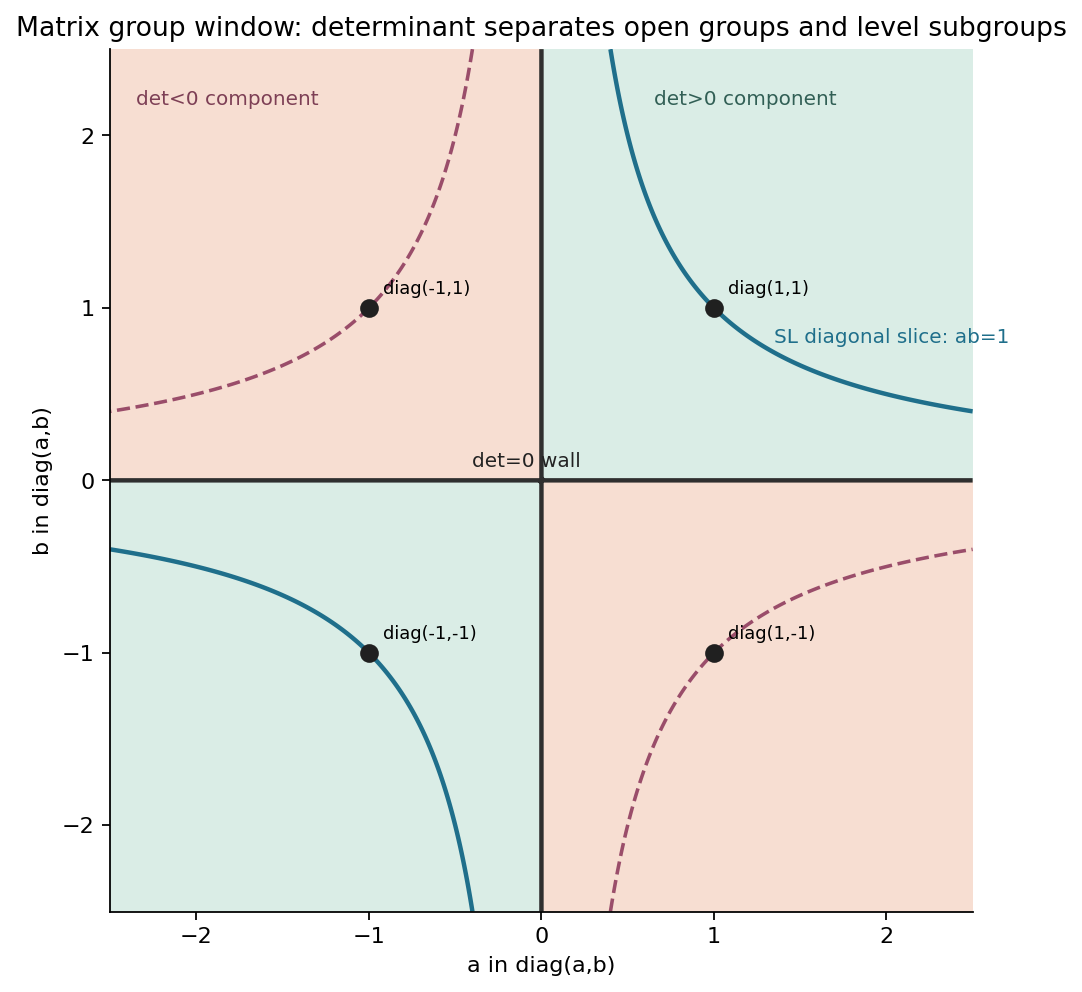

In [4]:
a_vals = np.linspace(-2.5, 2.5, 401)
b_vals = np.linspace(-2.5, 2.5, 401)
Agrid, Bgrid = np.meshgrid(a_vals, b_vals)
DET = Agrid * Bgrid

fig, ax = plt.subplots(figsize=(7.5, 7))
positive = ax.contourf(Agrid, Bgrid, DET, levels=[-10, 0, 10], colors=["#f4d0c0", "#cbe6dc"], alpha=0.7)
ax.contour(Agrid, Bgrid, DET, levels=[0], colors="#2f2f2f", linewidths=2.0)
ax.contour(Agrid, Bgrid, DET, levels=[1], colors="#1f6f8b", linewidths=2.0)
ax.contour(Agrid, Bgrid, DET, levels=[-1], colors="#9a4d6a", linestyles="--", linewidths=1.6)
for s1 in [-1, 1]:
    for s2 in [-1, 1]:
        ax.scatter([s1], [s2], color="#202020", s=55, zorder=5)
        ax.text(s1 + 0.08, s2 + 0.08, f"diag({s1},{s2})", fontsize=8)
ax.text(1.35, 0.8, "SL diagonal slice: ab=1", color="#1f6f8b", fontsize=9)
ax.text(-2.35, 2.18, "det<0 component", color="#7d3f55", fontsize=9)
ax.text(0.65, 2.18, "det>0 component", color="#315f55", fontsize=9)
ax.text(-0.4, 0.08, "det=0 wall", color="#222222", fontsize=9)
ax.set_xlabel("a in diag(a,b)")
ax.set_ylabel("b in diag(a,b)")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Matrix group window: determinant separates open groups and level subgroups")
matrix_path = save_matplotlib(fig, FIGURES / "matrix-groups-det-levels.png")
plt.close(fig)

x11, x12, x21, x22 = sp.symbols("x11 x12 x21 x22")
y11, y12, y21, y22 = sp.symbols("y11 y12 y21 y22")
X = sp.Matrix([[x11, x12], [x21, x22]])
Y = sp.Matrix([[y11, y12], [y21, y22]])
det_mult_residual = sp.factor((X * Y).det() - X.det() * Y.det())
B11, B12, B21, B22 = sp.symbols("B11 B12 B21 B22")
B = sp.Matrix([[B11, B12], [B21, B22]])
d_phi_identity = B.T + B
sym_basis = [
    sp.Matrix([[1, 0], [0, 0]]),
    sp.Matrix([[0, 1], [1, 0]]),
    sp.Matrix([[0, 0], [0, 1]]),
]
rank_phi_at_identity = len(sym_basis)
rotation = np.array([[math.cos(0.8), -math.sin(0.8)], [math.sin(0.8), math.cos(0.8)]])
orthogonal_residual = float(np.linalg.norm(rotation.T @ rotation - np.eye(2)))

matrix_checks = {
    "determinant_multiplicativity_residual": str(det_mult_residual),
    "d_phi_identity_formula": "B.T + B for Phi(A)=A.T@A",
    "rank_d_phi_identity_for_n_2": rank_phi_at_identity,
    "dimension_O2": 1,
    "dimension_SL2R": 3,
    "sample_SO2_orthogonality_residual": orthogonal_residual,
    "checks": {
        "determinant_multiplicativity_exact": bool(det_mult_residual == 0),
        "orthogonality_residual_small": bool(orthogonal_residual < 1e-12),
        "rank_matches_symmetric_2x2_dimension": bool(rank_phi_at_identity == 3),
    },
}
matrix_check_path = save_json(matrix_checks, CHECKS / "matrix-subgroup-invariants.json")
display_chapter_artifact(matrix_path, width=720)


Inspection target: `SL(2,R)` appears as a kernel of the determinant homomorphism,
while `SO(2)` appears as a determinant-positive part of the orthogonal level set.
The notebook check records both the exact determinant identity and the rank count
behind the dimension of `O(2)`.


## 3. Homomorphisms and Universal Covering Models

A Lie group homomorphism respects multiplication and is smooth. The chapter's
basic covering example is the map

`epsilon(t) = exp(2 pi i t): R -> S^1`.

It is a homomorphism from addition to circle multiplication, and all integers map
to the identity. That kernel is the computational trace of the covering behavior.


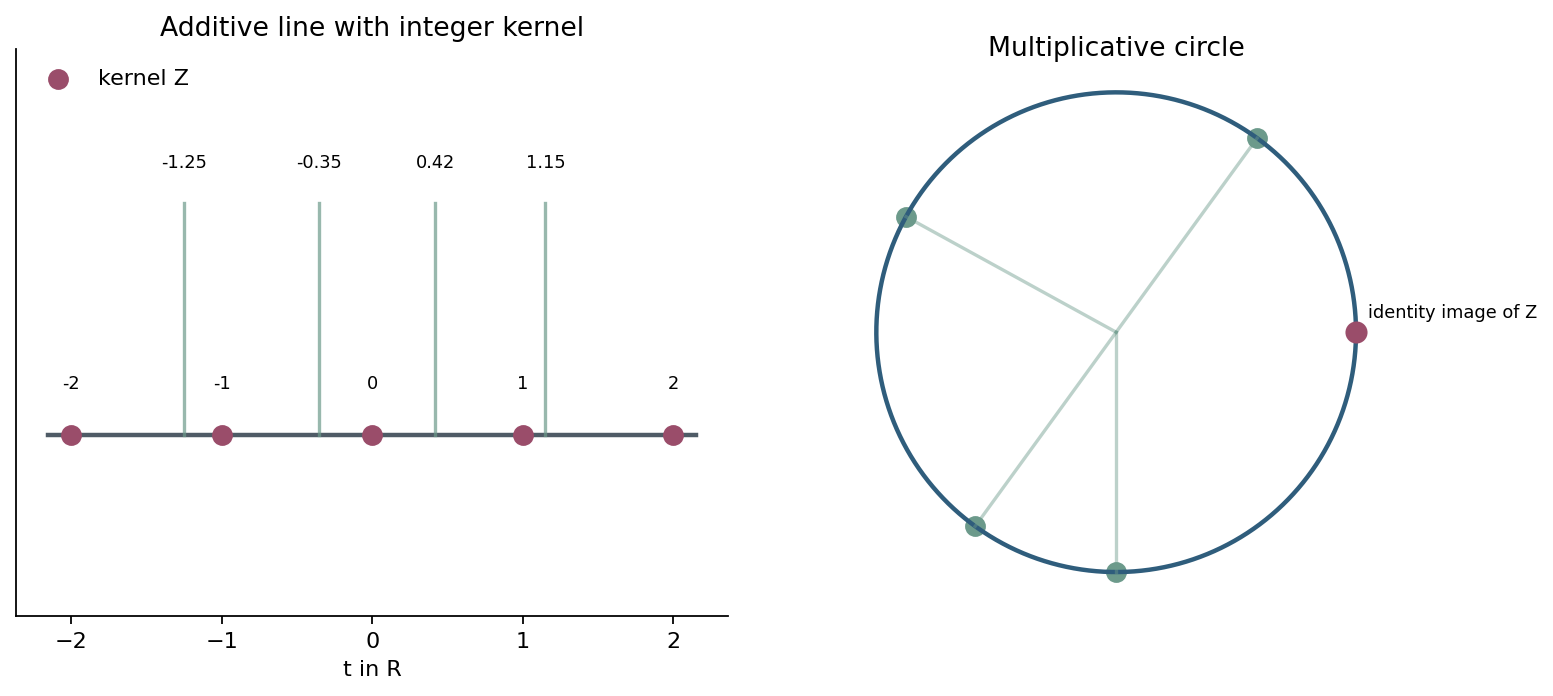

In [5]:
t = np.linspace(-2.15, 2.15, 500)
circle = np.exp(2j * np.pi * t)
kernels = np.arange(-2, 3)

fig, (ax_line, ax_circle) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1.35, 1]})
ax_line.plot(t, np.zeros_like(t), color="#4f5b66", linewidth=2)
ax_line.scatter(kernels, np.zeros_like(kernels), color="#9a4d6a", s=70, zorder=5, label="kernel Z")
for k in kernels:
    ax_line.text(k, 0.09, str(k), ha="center", fontsize=8)
for sample in [-1.25, -0.35, 0.42, 1.15]:
    z = np.exp(2j * np.pi * sample)
    ax_line.plot([sample, sample], [0, 0.45], color="#6c9a8b", alpha=0.7)
    ax_line.text(sample, 0.52, f"{sample:.2f}", ha="center", fontsize=8)
ax_line.set_ylim(-0.35, 0.75)
ax_line.set_yticks([])
ax_line.set_xlabel("t in R")
ax_line.set_title("Additive line with integer kernel")
ax_line.legend(loc="upper left", frameon=False)

angles = np.linspace(0, 2 * np.pi, 400)
ax_circle.plot(np.cos(angles), np.sin(angles), color="#2f5d7c", linewidth=2)
for sample in [-1.25, -0.35, 0.42, 1.15]:
    z = np.exp(2j * np.pi * sample)
    ax_circle.scatter([z.real], [z.imag], s=70, color="#6c9a8b")
    ax_circle.plot([0, z.real], [0, z.imag], color="#6c9a8b", alpha=0.45)
ax_circle.scatter([1], [0], color="#9a4d6a", s=80, zorder=6)
ax_circle.text(1.05, 0.06, "identity image of Z", fontsize=8)
ax_circle.set_aspect("equal", adjustable="box")
ax_circle.set_title("Multiplicative circle")
ax_circle.axis("off")
hom_path = save_matplotlib(fig, FIGURES / "homomorphism-covering-circle.png")
plt.close(fig)

samples = [(-0.7, 1.9), (0.125, 0.375), (math.sqrt(2) / 5, 0.8)]
hom_residuals = []
for s, u in samples:
    left = np.exp(2j * np.pi * (s + u))
    right = np.exp(2j * np.pi * s) * np.exp(2j * np.pi * u)
    hom_residuals.append(abs(left - right))
kernel_residuals = [abs(np.exp(2j * np.pi * k) - 1) for k in kernels]

hom_checks = {
    "map": "epsilon(t)=exp(2*pi*i*t)",
    "sample_homomorphism_residuals": [float(x) for x in hom_residuals],
    "kernel_samples": kernels.tolist(),
    "kernel_residuals": [float(x) for x in kernel_residuals],
    "covering_window": "physical source pages 168-191; printed pages 150-173",
    "checks": {
        "homomorphism_residuals_small": bool(max(hom_residuals) < 1e-12),
        "integer_kernel_samples_hit_identity": bool(max(kernel_residuals) < 1e-12),
    },
}
hom_check_path = save_json(hom_checks, CHECKS / "homomorphism-covering-kernel.json")
display_chapter_artifact(hom_path, width=880)


The picture separates two facts that often blur together. The map is locally a
diffeomorphism after wrapping, but globally it is not injective because every
integer lands on the same circle point. That same pattern becomes the universal
covering group model for tori.


## 4. Lie Subgroups: Embedded, Kernel, and Dense Immersed Cases

Kernels of homomorphisms are the cleanest subgroup examples because they are
level sets over the identity. Injective homomorphisms give immersed images, but
the image need not be embedded. A one-parameter subgroup with irrational slope in
the torus is the standard warning sign: locally it looks like a curve, globally it
threads through the torus densely.


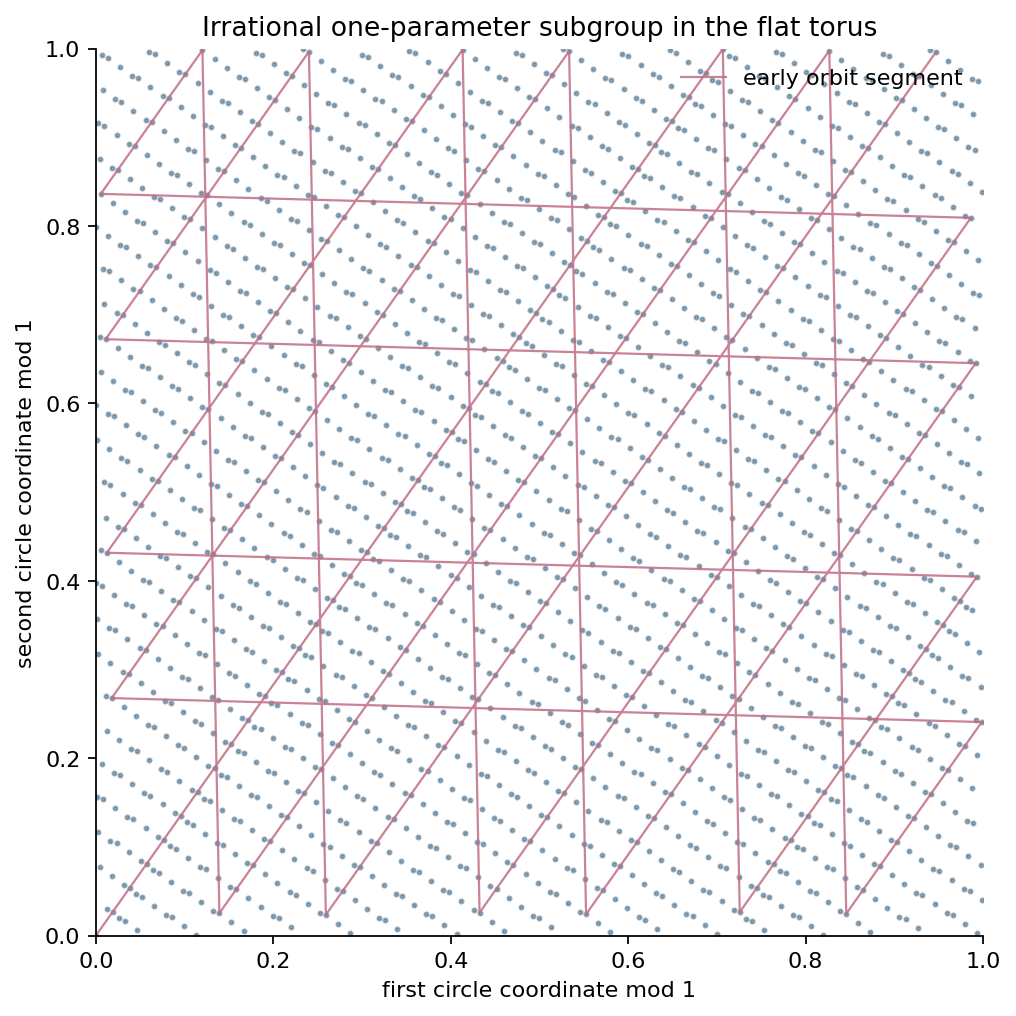

In [6]:
alpha = math.sqrt(2)
s = np.linspace(0, 42, 2200)
torus_points = np.column_stack(((s % 1.0), ((alpha * s) % 1.0)))

fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.scatter(torus_points[:, 0], torus_points[:, 1], s=3, color="#365f7c", alpha=0.48)
ax.plot(torus_points[:260, 0], torus_points[:260, 1], color="#c06c84", linewidth=1.0, alpha=0.85, label="early orbit segment")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("first circle coordinate mod 1")
ax.set_ylabel("second circle coordinate mod 1")
ax.set_title("Irrational one-parameter subgroup in the flat torus")
ax.legend(loc="upper right", frameon=False)
dense_path = save_matplotlib(fig, FIGURES / "dense-torus-subgroup.png")
plt.close(fig)

bins = 18
hist, _, _ = np.histogram2d(torus_points[:, 0], torus_points[:, 1], bins=bins, range=[[0, 1], [0, 1]])
coverage_ratio = float(np.count_nonzero(hist) / hist.size)
closed_slope_points = np.column_stack(((np.linspace(0, 1, 200) % 1.0), ((2 * np.linspace(0, 1, 200)) % 1.0)))
dense_checks = {
    "map": "s -> (exp(2*pi*i*s), exp(2*pi*i*sqrt(2)*s))",
    "sample_count": int(len(torus_points)),
    "histogram_bins_per_axis": bins,
    "visited_box_ratio": coverage_ratio,
    "comparison": "rational slopes close up; irrational slope samples spread through the torus",
    "checks": {
        "irrational_sample_visits_most_boxes": bool(coverage_ratio > 0.93),
        "slope_is_irrational_model": bool(abs(alpha - round(alpha)) > 0.1),
    },
}
dense_check_path = save_json(dense_checks, CHECKS / "dense-torus-subgroup.json")
display_chapter_artifact(dense_path, width=680)


This is the chapter's most useful failure mode. The subgroup law is perfectly
good and the homomorphism is injective, but the image topology inherited from the
torus is not the same as the line topology. That is why the chapter distinguishes
immersed Lie subgroups from embedded ones.


## 5. Smooth Actions, Orbits, and Stabilizers

A smooth action is a Lie group worth of diffeomorphisms of a manifold. For the
`SO(2)` action on the plane, the orbit through a nonzero point is a circle; the
origin is fixed by every group element. Thus the stabilizer changes from trivial
for nonzero points to the whole group at the origin.


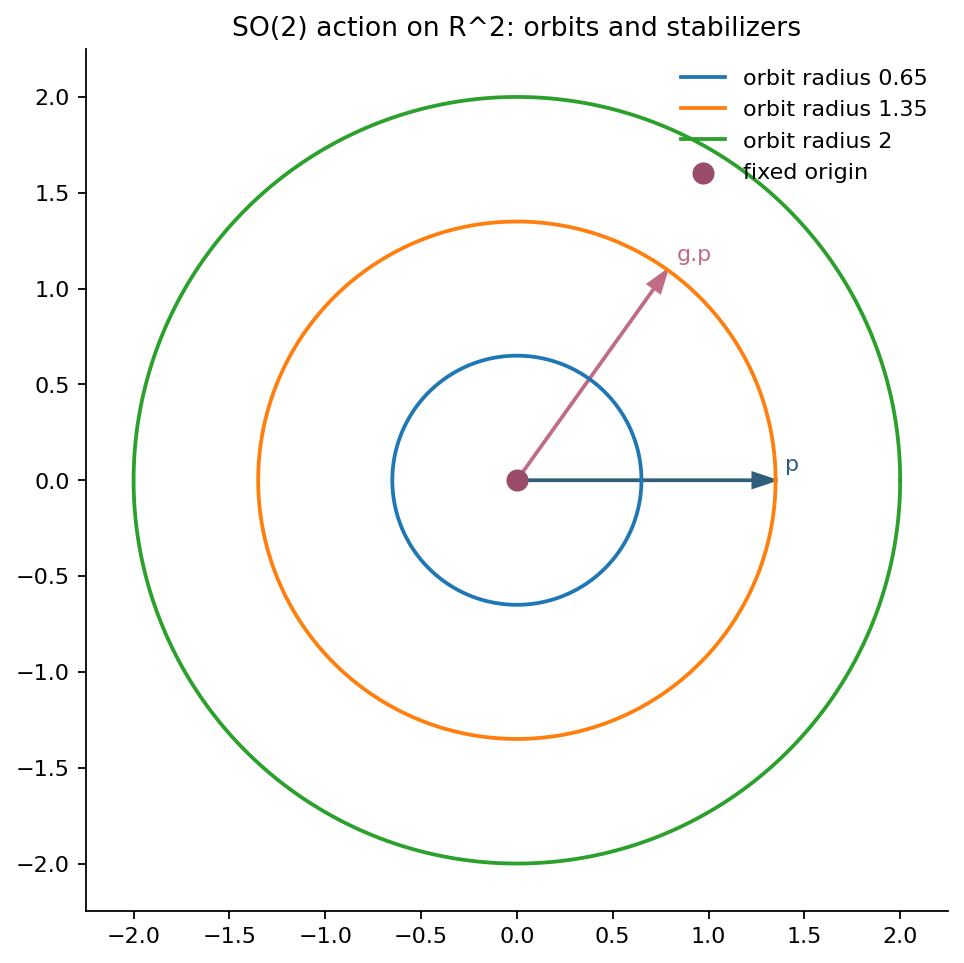

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [7]:
angles = np.linspace(0, 2 * np.pi, 361)
radii = [0.0, 0.65, 1.35, 2.0]
fig, ax = plt.subplots(figsize=(7.5, 7))
for radius in radii[1:]:
    ax.plot(radius * np.cos(angles), radius * np.sin(angles), linewidth=1.7, label=f"orbit radius {radius:g}")
ax.scatter([0], [0], color="#9a4d6a", s=80, zorder=5, label="fixed origin")
p = np.array([1.35, 0.0])
theta0 = 0.95
R0 = np.array([[math.cos(theta0), -math.sin(theta0)], [math.sin(theta0), math.cos(theta0)]])
q = R0 @ p
ax.arrow(0, 0, p[0], p[1], width=0.008, head_width=0.08, color="#2f5d7c", length_includes_head=True)
ax.arrow(0, 0, q[0], q[1], width=0.008, head_width=0.08, color="#c06c84", length_includes_head=True)
ax.text(p[0] + 0.05, p[1] + 0.05, "p", color="#2f5d7c")
ax.text(q[0] + 0.05, q[1] + 0.05, "g.p", color="#c06c84")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-2.25, 2.25)
ax.set_ylim(-2.25, 2.25)
ax.set_title("SO(2) action on R^2: orbits and stabilizers")
ax.legend(loc="upper right", frameon=False)
action_path = save_matplotlib(fig, FIGURES / "actions-orbits-stabilizers.png")
plt.close(fig)

frames = []
triangle = np.array([[1.2, 0.0], [0.25, 0.55], [0.25, -0.55], [1.2, 0.0]])
for idx, th in enumerate(np.linspace(0, 2 * np.pi, 30)):
    R = np.array([[math.cos(th), -math.sin(th)], [math.sin(th), math.cos(th)]])
    moved = triangle @ R.T
    frames.append(go.Frame(
        data=[go.Scatter(x=moved[:, 0], y=moved[:, 1], mode="lines+markers", line=dict(color="#c06c84", width=3))],
        name=str(idx),
    ))
fig_html = go.Figure(
    data=[go.Scatter(x=triangle[:, 0], y=triangle[:, 1], mode="lines+markers", line=dict(color="#c06c84", width=3))],
    frames=frames,
)
fig_html.update_layout(
    title="SO(2) action as a one-parameter family of diffeomorphisms",
    xaxis=dict(range=[-1.5, 1.5], scaleanchor="y", scaleratio=1, zeroline=True),
    yaxis=dict(range=[-1.5, 1.5], zeroline=True),
    width=720,
    height=640,
    margin=dict(l=20, r=20, t=55, b=20),
    updatemenus=[{
        "type": "buttons",
        "buttons": [
            {"label": "Play", "method": "animate", "args": [None, {"frame": {"duration": 70, "redraw": True}, "fromcurrent": True}]},
            {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]},
        ],
    }],
)
action_html_path = save_plotly_html(fig_html, HTML / "so2-action-orbits.html")

sample_angles = np.linspace(0, 2 * np.pi, 121)
orbit = np.array([np.array([[math.cos(th), -math.sin(th)], [math.sin(th), math.cos(th)]]) @ p for th in sample_angles])
radius_residual = float(np.max(np.abs(np.linalg.norm(orbit, axis=1) - np.linalg.norm(p))))
nonzero_fix_residuals = [float(np.linalg.norm(np.array([[math.cos(th), -math.sin(th)], [math.sin(th), math.cos(th)]]) @ p - p)) for th in [0, 0.1, 1.7, 3.0]]
origin_fix_residuals = [float(np.linalg.norm(np.array([[math.cos(th), -math.sin(th)], [math.sin(th), math.cos(th)]]) @ np.zeros(2))) for th in [0, 0.1, 1.7, 3.0]]
orbit_map_rank_nonzero = 1
orbit_map_rank_origin = 0

action_checks = {
    "group": "SO(2)",
    "manifold": "R^2",
    "orbit_nonzero_rank": orbit_map_rank_nonzero,
    "orbit_origin_rank": orbit_map_rank_origin,
    "max_radius_residual_for_nonzero_orbit": radius_residual,
    "sample_nonzero_fixed_residuals": nonzero_fix_residuals,
    "sample_origin_fixed_residuals": origin_fix_residuals,
    "stabilizer_summary": {
        "origin": "all of SO(2)",
        "nonzero_sample_point": "identity only in SO(2)",
    },
    "checks": {
        "radius_preserved": bool(radius_residual < 1e-12),
        "origin_fixed_by_all_sampled_rotations": bool(max(origin_fix_residuals) < 1e-12),
        "nonidentity_sample_moves_nonzero_point": bool(min(nonzero_fix_residuals[1:]) > 1e-3),
    },
}
action_check_path = save_json(action_checks, CHECKS / "action-orbit-stabilizer.json")
display_chapter_artifact(action_path, width=700)
display_chapter_artifact(action_html_path, width=740, height=660)


The orbit map viewpoint is doing the work: `theta -> R_theta p` has rank one for
`p != 0`, and rank zero at the origin. The stabilizer is the fiber of that orbit map
over the starting point.


## 6. Equivariant Maps and Constant Rank

Equivariance says that applying a group element before a map gives the same
answer as applying the group element after the map. When the action on the domain
is transitive, the group can move any tangent-space calculation to any other point.
That is the geometric reason behind the equivariant rank theorem.


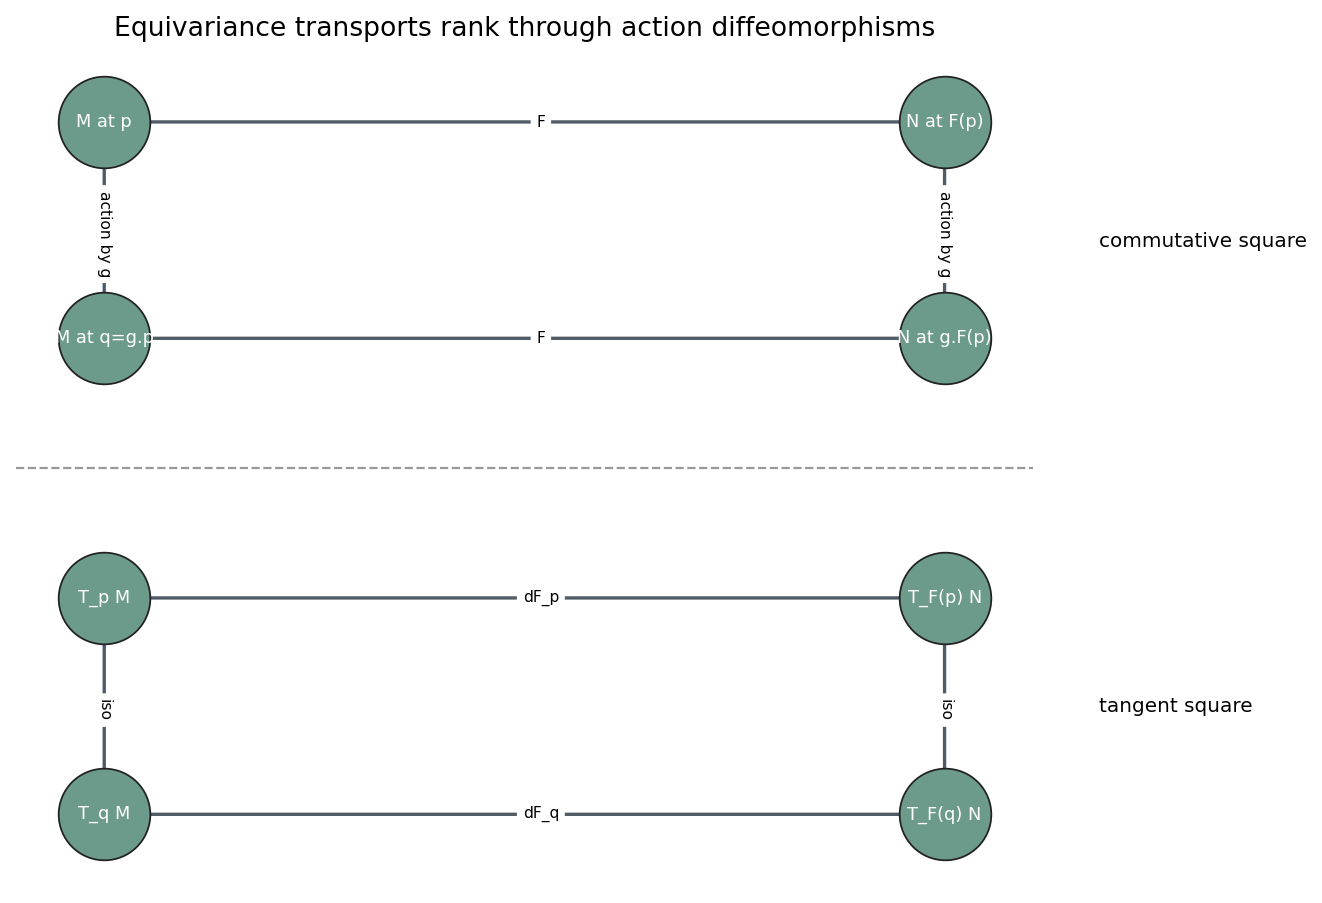

In [8]:
Geq = nx.DiGraph()
Geq.add_edges_from([
    ("M at p", "N at F(p)"),
    ("M at q=g.p", "N at g.F(p)"),
    ("M at p", "M at q=g.p"),
    ("N at F(p)", "N at g.F(p)"),
    ("T_p M", "T_F(p) N"),
    ("T_q M", "T_F(q) N"),
    ("T_p M", "T_q M"),
    ("T_F(p) N", "T_F(q) N"),
])
pos_eq = {
    "M at p": (0, 2),
    "N at F(p)": (3, 2),
    "M at q=g.p": (0, 1),
    "N at g.F(p)": (3, 1),
    "T_p M": (0, -0.2),
    "T_F(p) N": (3, -0.2),
    "T_q M": (0, -1.2),
    "T_F(q) N": (3, -1.2),
}
labels = {
    ("M at p", "N at F(p)"): "F",
    ("M at q=g.p", "N at g.F(p)"): "F",
    ("M at p", "M at q=g.p"): "action by g",
    ("N at F(p)", "N at g.F(p)"): "action by g",
    ("T_p M", "T_F(p) N"): "dF_p",
    ("T_q M", "T_F(q) N"): "dF_q",
    ("T_p M", "T_q M"): "iso",
    ("T_F(p) N", "T_F(q) N"): "iso",
}
fig, ax = plt.subplots(figsize=(8.2, 6.8))
nx.draw_networkx_edges(Geq, pos_eq, ax=ax, arrows=True, arrowstyle="-|>", width=1.5, edge_color="#4f5b66")
nx.draw_networkx_nodes(Geq, pos_eq, ax=ax, node_color="#6c9a8b", node_size=1700, edgecolors="#222222", linewidths=0.8)
nx.draw_networkx_labels(Geq, pos_eq, ax=ax, font_size=8, font_color="white")
nx.draw_networkx_edge_labels(Geq, pos_eq, edge_labels=labels, ax=ax, font_size=7, label_pos=0.52)
ax.axhline(0.4, color="#999999", linewidth=1, linestyle="--")
ax.text(3.55, 1.45, "commutative square", fontsize=9, va="center")
ax.text(3.55, -0.7, "tangent square", fontsize=9, va="center")
ax.set_title("Equivariance transports rank through action diffeomorphisms")
ax.axis("off")
eq_path = save_matplotlib(fig, FIGURES / "equivariant-rank-diagram.png")
plt.close(fig)

v = np.array([1.0, math.sqrt(2)])
xs = np.array([[0.2, 0.4], [0.8, -0.1], [-1.2, 0.25]])
times = [0.0, 0.3, -1.1, 2.0]
equivariance_residuals = []
for x in xs:
    for time in times:
        lhs = np.exp(2j * np.pi * (x + time * v))
        rhs = np.exp(2j * np.pi * time * v) * np.exp(2j * np.pi * x)
        equivariance_residuals.append(float(np.linalg.norm(lhs - rhs)))

# The map epsilon_2: R^2 -> T^2 has Jacobian columns that are never zero as a real
# map into two circle coordinates, so its local rank is 2 everywhere.
rank_samples = [2 for _ in xs]
eq_checks = {
    "map": "epsilon_2(x1,x2)=(exp(2*pi*i*x1), exp(2*pi*i*x2))",
    "action_vector": v.tolist(),
    "sample_equivariance_residuals": equivariance_residuals,
    "rank_samples_for_covering_map": rank_samples,
    "diagram_artifact": rel(eq_path),
    "checks": {
        "equivariance_residuals_small": bool(max(equivariance_residuals) < 1e-12),
        "rank_constant_in_samples": bool(len(set(rank_samples)) == 1 and rank_samples[0] == 2),
    },
}
eq_check_path = save_json(eq_checks, CHECKS / "equivariant-rank-check.json")
display_chapter_artifact(eq_path, width=760)


The theorem is not saying every equivariant map is interesting; it is saying that
transitivity on the domain removes rank jumps. The vertical arrows in the tangent
square are linear isomorphisms, so the two horizontal maps must have the same
rank.


## 7. Semidirect Product Lab: The Euclidean Group

The Euclidean group is the chapter's most visual semidirect product:

`E(2) = R^2 semidirect O(2)`.

The smooth manifold is a product, but the multiplication is twisted:

`(b,A)(c,B) = (b + A c, A B)`.

The action on the plane sends `x` to `b + A x`. This is a compact laboratory for
checking the action law, inverse formula, and geometric invariants.


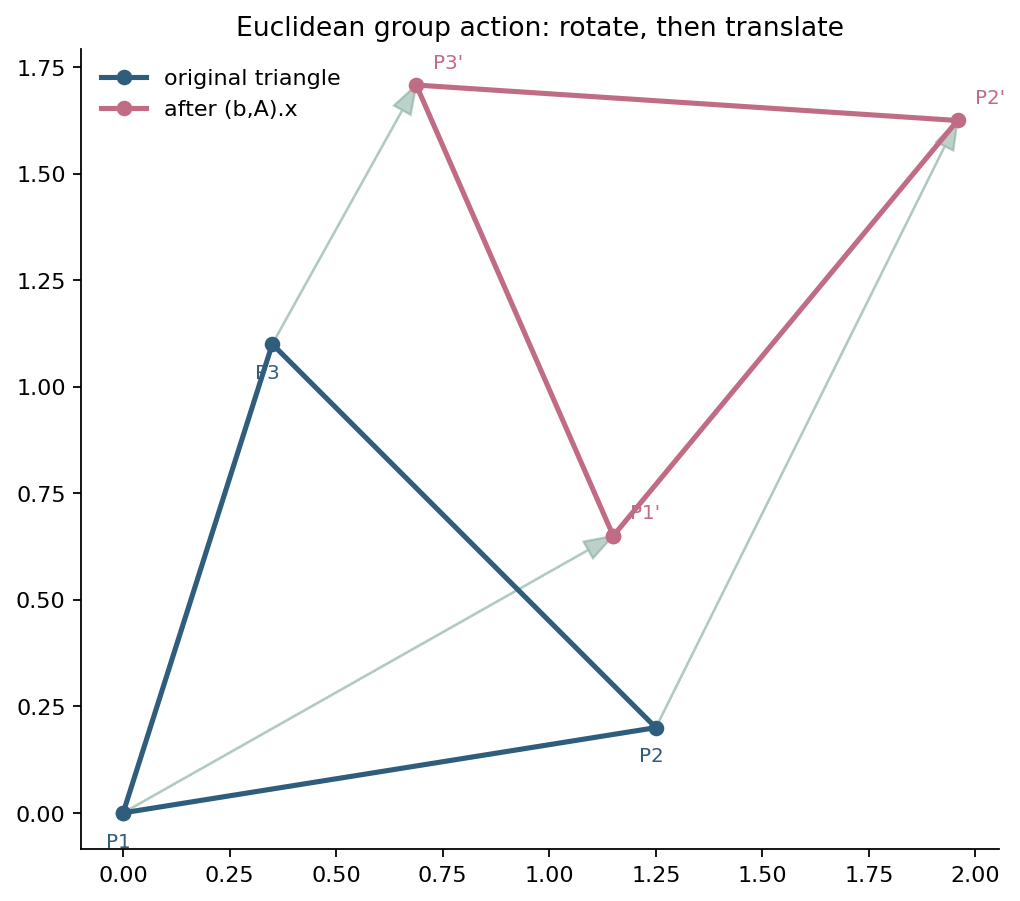

In [9]:
def rot(th: float) -> np.ndarray:
    return np.array([[math.cos(th), -math.sin(th)], [math.sin(th), math.cos(th)]])

def e_mul(g, h):
    b, A = g
    c, B = h
    return (b + A @ c, A @ B)

def e_inv(g):
    b, A = g
    return (-A.T @ b, A.T)

def e_act(g, x):
    b, A = g
    return b + A @ x

triangle = np.array([[0.0, 0.0], [1.25, 0.2], [0.35, 1.1], [0.0, 0.0]])
g = (np.array([1.15, 0.65]), rot(0.72))
h = (np.array([-0.25, 0.85]), rot(-0.38))
moved = np.array([e_act(g, x) for x in triangle])

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.plot(triangle[:, 0], triangle[:, 1], "o-", color="#2f5d7c", linewidth=2.3, label="original triangle")
ax.plot(moved[:, 0], moved[:, 1], "o-", color="#c06c84", linewidth=2.3, label="after (b,A).x")
for i, (x0, x1) in enumerate(zip(triangle[:-1], moved[:-1]), start=1):
    ax.arrow(x0[0], x0[1], x1[0] - x0[0], x1[1] - x0[1], color="#6c9a8b", alpha=0.45, length_includes_head=True, head_width=0.045)
    ax.text(x0[0] - 0.04, x0[1] - 0.08, f"P{i}", color="#2f5d7c", fontsize=9)
    ax.text(x1[0] + 0.04, x1[1] + 0.04, f"P{i}'", color="#c06c84", fontsize=9)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Euclidean group action: rotate, then translate")
ax.legend(frameon=False)
semi_path = save_matplotlib(fig, FIGURES / "semidirect-euclidean-action.png")
plt.close(fig)

left_assoc = e_mul(e_mul(g, h), (np.array([0.4, -0.2]), rot(0.21)))
right_assoc = e_mul(g, e_mul(h, (np.array([0.4, -0.2]), rot(0.21))))
assoc_residual = float(np.linalg.norm(left_assoc[0] - right_assoc[0]) + np.linalg.norm(left_assoc[1] - right_assoc[1]))
identity = (np.zeros(2), np.eye(2))
inv_left = e_mul(e_inv(g), g)
inverse_residual = float(np.linalg.norm(inv_left[0] - identity[0]) + np.linalg.norm(inv_left[1] - identity[1]))
edge_lengths_before = np.linalg.norm(np.diff(triangle, axis=0), axis=1)
edge_lengths_after = np.linalg.norm(np.diff(moved, axis=0), axis=1)
distance_residual = float(np.max(np.abs(edge_lengths_before - edge_lengths_after)))
area_before = 0.5 * abs(np.linalg.det(np.column_stack((triangle[1] - triangle[0], triangle[2] - triangle[0]))))
area_after = 0.5 * abs(np.linalg.det(np.column_stack((moved[1] - moved[0], moved[2] - moved[0]))))
area_residual = float(abs(area_before - area_after))

semi_checks = {
    "multiplication": "(b,A)(c,B)=(b+A c, A B)",
    "inverse": "(b,A)^-1=(-A.T b, A.T) for A in SO(2)",
    "associativity_sample_residual": assoc_residual,
    "inverse_sample_residual": inverse_residual,
    "max_edge_length_residual": distance_residual,
    "triangle_area_residual": area_residual,
    "checks": {
        "associativity_sample_small": bool(assoc_residual < 1e-12),
        "inverse_sample_small": bool(inverse_residual < 1e-12),
        "distances_preserved": bool(distance_residual < 1e-12),
        "area_preserved_for_rotation_translation": bool(area_residual < 1e-12),
    },
}
semi_check_path = save_json(semi_checks, CHECKS / "semidirect-euclidean-group.json")
display_chapter_artifact(semi_path, width=720)


The lab gives a concrete meaning to "action by automorphisms." The rotation
matrix acts on translations before translations are added. That twist is exactly
what makes Euclidean motions compose correctly.


## 8. Representations

A representation is a Lie group homomorphism into `GL(V)`. Faithful
representations let us realize a Lie group as a matrix Lie subgroup. The chapter
does not develop representation theory deeply, but it gives enough examples to
track kernels and faithful models.


In [10]:
representation_rows = [
    {
        "group": "S^1",
        "target": "GL(1,C)",
        "formula": "z -> [z]",
        "faithful": "yes",
        "kernel": "{1}",
        "inspection": "circle as unit complex matrices",
    },
    {
        "group": "T^n",
        "target": "GL(n,C)",
        "formula": "(z1,...,zn) -> diag(z1,...,zn)",
        "faithful": "yes",
        "kernel": "{identity}",
        "inspection": "diagonal entries remember every torus coordinate",
    },
    {
        "group": "R^n additive",
        "target": "GL(n+1,R)",
        "formula": "x -> [[I,x],[0,1]]",
        "faithful": "yes",
        "kernel": "{0}",
        "inspection": "translations represented by affine block matrices",
    },
    {
        "group": "R^n additive",
        "target": "GL(n,C)",
        "formula": "x -> diag(exp(2*pi*i*xj))",
        "faithful": "no",
        "kernel": "Z^n",
        "inspection": "periodic coordinates lose integer shifts",
    },
    {
        "group": "E(n)",
        "target": "GL(n+1,R)",
        "formula": "(b,A) -> [[A,b],[0,1]]",
        "faithful": "yes",
        "kernel": "{identity motion}",
        "inspection": "Euclidean motions as affine matrices",
    },
]
representation_table_path = save_csv(representation_rows, TABLES / "representation-examples.csv")

x1, x2, y1, y2 = sp.symbols("x1 x2 y1 y2")
rho_x = sp.Matrix([[1, 0, x1], [0, 1, x2], [0, 0, 1]])
rho_y = sp.Matrix([[1, 0, y1], [0, 1, y2], [0, 0, 1]])
rho_xy = sp.Matrix([[1, 0, x1 + y1], [0, 1, x2 + y2], [0, 0, 1]])
translation_rep_residual = sp.simplify(rho_x * rho_y - rho_xy)
periodic_kernel_sample = np.diag(np.exp(2j * np.pi * np.array([2, -3, 0])))
periodic_kernel_residual = float(np.linalg.norm(periodic_kernel_sample - np.eye(3)))

representation_checks = {
    "translation_block_representation_residual": str(translation_rep_residual),
    "periodic_diagonal_kernel_sample": [2, -3, 0],
    "periodic_diagonal_kernel_residual": periodic_kernel_residual,
    "table_artifact": rel(representation_table_path),
    "checks": {
        "translation_block_is_homomorphism": bool(translation_rep_residual == sp.zeros(3, 3)),
        "integer_vectors_in_periodic_kernel": bool(periodic_kernel_residual < 1e-12),
    },
}
representation_check_path = save_json(representation_checks, CHECKS / "representation-checks.json")
display_chapter_artifact(representation_table_path)
print(json.dumps(representation_checks, indent=2))


[representation-examples.csv](../artifacts/chapter-07-lie-groups/tables/representation-examples.csv)

{
  "translation_block_representation_residual": "Matrix([[0, 0, 0], [0, 0, 0], [0, 0, 0]])",
  "periodic_diagonal_kernel_sample": [
    2,
    -3,
    0
  ],
  "periodic_diagonal_kernel_residual": 8.831053657317262e-16,
  "table_artifact": "artifacts/chapter-07-lie-groups/tables/representation-examples.csv",
  "checks": {
    "translation_block_is_homomorphism": true,
    "integer_vectors_in_periodic_kernel": true
  }
}


The table should be read as a map of failure and success modes. A faithful
representation remembers the group element; a nonfaithful one still respects the
group law but collapses a nontrivial kernel.


## Applied Lab

Use the artifacts as small experiments rather than as final answers.

1. Change the slope in the torus subgroup from `sqrt(2)` to `2`. Predict whether
the point cloud remains dense, then rerun the histogram coverage check.
2. Replace the rotation matrix in the Euclidean group lab by a scaling matrix.
The group law still composes affine maps, but the distance-preservation check
should fail.
3. In the action section, move the sample point `p` to the origin. The orbit-map
rank should drop and the stabilizer should grow.
4. In the representation section, change the periodic diagonal sample from an
integer vector to a noninteger vector. The kernel residual should no longer vanish.


## Computational Checks

The final check cell gathers the chapter invariants:

- smooth group model checks on `S^1`
- determinant multiplicativity and orthogonal level-set residuals
- homomorphism residuals and integer kernel samples for `R -> S^1`
- dense torus coverage for an irrational one-parameter subgroup
- orbit/stabilizer rank and fixed-point checks for the `SO(2)` action
- equivariance residuals and constant rank samples
- semidirect product associativity, inverse, distance, and area checks
- representation homomorphism and kernel checks
- artifact existence and nonzero file size checks

The resulting `final_sanity.json` is part of the artifact contract for this
chapter.


In [11]:
artifact_paths = [
    library_routing_path,
    concept_inventory_path,
    structure_path,
    s1_check_path,
    matrix_path,
    matrix_check_path,
    hom_path,
    hom_check_path,
    dense_path,
    dense_check_path,
    action_path,
    action_html_path,
    action_check_path,
    eq_path,
    eq_check_path,
    semi_path,
    semi_check_path,
    representation_table_path,
    representation_check_path,
]
assert_artifacts(artifact_paths, min_bytes=80)

check_reports = {
    "s1": s1_checks["checks"],
    "matrix": matrix_checks["checks"],
    "homomorphism": hom_checks["checks"],
    "dense_subgroup": dense_checks["checks"],
    "action": action_checks["checks"],
    "equivariant_rank": eq_checks["checks"],
    "semidirect": semi_checks["checks"],
    "representations": representation_checks["checks"],
}
failed = {
    section: [name for name, passed in checks.items() if not bool(passed)]
    for section, checks in check_reports.items()
}
failed = {section: names for section, names in failed.items() if names}
if failed:
    raise AssertionError(f"Chapter 7 failed checks: {failed}")

final_sanity = {
    "unit": UNIT_TITLE,
    "source_span": {
        "pdf": "Introduction to Smooth Manifolds.pdf",
        "printed_pages": "150-173",
        "physical_pages_inspected": "168-191",
        "source_map_focus": "Basic Lie groups, homomorphisms, subgroups, actions, equivariant maps, and examples.",
    },
    "concepts_covered": [
        "Lie group definition",
        "left and right translations",
        "matrix Lie groups",
        "Lie group homomorphisms",
        "universal covering group examples",
        "embedded and immersed Lie subgroups",
        "closed versus embedded subgroup behavior",
        "group actions",
        "orbits and stabilizers",
        "equivariant maps and constant rank",
        "orthogonal and special orthogonal groups",
        "semidirect products",
        "representations",
    ],
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": check_reports,
    "all_checks_passed": True,
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=200)
display_chapter_artifact(final_sanity_path)
print(json.dumps(final_sanity, indent=2))


`final_sanity.json`

{
  "unit": "Lie Groups",
  "source_span": {
    "pdf": "Introduction to Smooth Manifolds.pdf",
    "printed_pages": "150-173",
    "physical_pages_inspected": "168-191",
    "source_map_focus": "Basic Lie groups, homomorphisms, subgroups, actions, equivariant maps, and examples."
  },
  "concepts_covered": [
    "Lie group definition",
    "left and right translations",
    "matrix Lie groups",
    "Lie group homomorphisms",
    "universal covering group examples",
    "embedded and immersed Lie subgroups",
    "closed versus embedded subgroup behavior",
    "group actions",
    "orbits and stabilizers",
    "equivariant maps and constant rank",
    "orthogonal and special orthogonal groups",
    "semidirect products",
    "representations"
  ],
  "artifacts": [
    "artifacts/chapter-07-lie-groups/tables/lie-groups-routing.csv",
    "artifacts/chapter-07-lie-groups/tables/concept-inventory.csv",
    "artifacts/chapter-07-lie-groups/figures/lie-group-structure-translations.png",
    "

## Takeaways

- Lie groups are smooth manifolds where the group operations are smooth enough to
turn multiplication by a fixed element into a diffeomorphism.
- Matrix groups are not just examples; they show the main construction patterns:
open subsets, kernels, level sets, and determinant components.
- Homomorphisms have constant rank because translations compare their
differentials at every point to the differential at the identity.
- Lie subgroups are more rigid than arbitrary immersed submanifolds: kernels are
properly embedded, injective images may be merely immersed, and closedness
matches embeddedness for Lie subgroups.
- Group actions turn abstract group elements into diffeomorphisms of a manifold;
orbits and stabilizers are the image and fiber of the orbit map.
- Equivariant maps are diagrammatic machines for constant-rank results.
- Semidirect products and representations explain how actions build new Lie
groups and how Lie groups can be studied through matrices.
